In [1]:
!pip install transformers torch scikit-learn doublemetaphone

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.7/172.7 kB 6.0 MB/s eta 0:00:00


In [2]:
!pip install datasets==3.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 14.8 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [3]:
!pip install jellyfish

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 8.4 MB/s eta 0:00:00


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import re
import unicodedata
import random
import os
import pandas as pd
from datasets import Dataset, concatenate_datasets
from transformers import AutoTokenizer
from torch.utils.data import DataLoader
from collections import defaultdict
import numpy as np
import jellyfish

import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.cuda.amp import GradScaler, autocast
from transformers import AutoModel, AutoTokenizer

In [ ]:
# class DataConfig:
#     # Model & Tokenizer Config
#     TOKENIZER_NAME = 'distilbert/distilbert-base-uncased'
#     MAX_SEQ_LENGTH = 128  # Max number of tokens in a sequence
#     MAX_CHARS_PER_TOKEN = 24 # Max characters for the Char-CNN

#     # Dataset Names from Hugging Face Hub
#     JIGSAW_NAME = 'google/jigsaw_toxicity_pred'
#     CIVIL_COMMENTS_NAME = 'google/civil_comments'
#     TOXIC_SPANS_NAME = 'sem_eval_2021_task_5'

#     # Batch Size for DataLoader
#     BATCH_SIZE = 16


# def substitute_leetspeak(text):
#     """Replaces characters with common leetspeak equivalents."""
#     leetspeak_map = str.maketrans({
#         'a': '@', 'e': '3', 'i': '!', 'o': '0', 's': '$', 't': '7'
#     })
#     return text.translate(leetspeak_map)

# def add_character_repetition(text, p=0.3):
#     """Randomly repeats characters in the text."""
#     new_text = ""
#     for char in text:
#         new_text += char
#         if char.isalpha() and random.random() < p:
#             new_text += char
#     return new_text

# def add_punctuation(text, p=0.3):
#     """Randomly inserts punctuation between letters."""
#     new_text = ""
#     for char in text:
#         new_text += char
#         if char.isalpha() and random.random() < p:
#             new_text += random.choice("._-!?,")
#     return new_text

# def apply_augmentations(text):
#     """Applies a random augmentation to the text."""
#     augmentations = [substitute_leetspeak, add_character_repetition, add_punctuation]
#     aug_func = random.choice(augmentations)
#     return aug_func(text)


In [5]:
class DataConfig:
    """
    Configuration for data loading and preprocessing.
    """
    TOKENIZER_NAME = 'distilbert-base-uncased'
    MAX_SEQ_LENGTH = 128
    MAX_CHARS_PER_TOKEN = 24
    JIGSAW_CSV_PATH = "train.csv" # Assumes train.csv is uploaded
    BATCH_SIZE = 32
    VALIDATION_SPLIT_PERCENT = 0.1


class ModelConfig:
    """
    Configuration for the OPTIMIZED model architecture.
    Reflects a smaller, more efficient design leveraging transfer learning.
    """
    # Vocab sizes are set dynamically in the main script from the preprocessor
    VOCAB_SIZE, CHAR_VOCAB_SIZE, PHONETIC_VOCAB_SIZE = 30522, 100, 5000

    # Dimensions for our custom-trained encoders
    CHAR_EMB_DIM = 32
    PHONETIC_EMB_DIM = 64

    # --- TUNED PARAMETERS for custom layers ---
    # Simplified Char-CNN as it's now an auxiliary signal
    CHAR_CNN_OUT_DIM = 96
    CHAR_CNN_FILTERS = [(2, 32), (3, 48)] # Simpler filter setup

    # Reduced dimensions for the fusion part, as the backbone does the heavy lifting
    FUSION_TRANSFORMER_LAYERS = 2
    FUSION_TRANSFORMER_HEADS = 4
    FUSED_DIM = 256 # Smaller bottleneck dimension

    # Simplified final classifier
    CLASSIFIER_HIDDEN_DIM = 96

    # Other fixed dimensions
    METADATA_DIM = 3
    DROPOUT = 0.2 # Slightly increased dropout for better regularization
    MAX_SEQ_LENGTH = 128

class TrainingConfig:
    """Configuration for the training process."""
    EPOCHS = 10
    LEARNING_RATE = 5e-5
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    PATIENCE = 2
    MODEL_SAVE_PATH = 'gcpf_net_best3.pth'
    PREPROCESSOR_SAVE_PATH = 'gcpf_preprocessor3.dill'

def apply_augmentations(text, p=0.1):
    if random.random() < p:
        text = text.translate(str.maketrans({'a': '@', 'e': '3', 'i': '!', 'o': '0', 's': '$', 't': '7'}))
    if random.random() < p:
        text = "".join([c * (2 if c.isalpha() and random.random() < 0.5 else 1) for c in text])
    if random.random() < p:
        text = "".join([c + (random.choice("._-") if c.isalpha() and random.random() < 0.5 else "") for c in text])
    return text

In [6]:
class GPCFPreprocessor:
    """Handles all text preprocessing steps."""
    def __init__(self, config):
        self.config = config
        self.tokenizer = AutoTokenizer.from_pretrained(config.TOKENIZER_NAME)
        self.char_vocab = self._build_vocab("abcdefghijklmnopqrstuvwxyz0123456789!\"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~ ")
        self.phonetic_vocab = defaultdict(lambda: len(self.phonetic_vocab))
        self.phonetic_vocab['<pad>'], self.phonetic_vocab['<unk>'] = 0, 1

    def _build_vocab(self, corpus):
        vocab = {'<pad>':0, '<unk>':1}; [vocab.setdefault(c, len(vocab)) for c in corpus]; return vocab

    def _normalize_text(self, text):
        if not isinstance(text, str): text = str(text)
        return re.sub(r"[\u200b-\u200d\ufeff]", "", unicodedata.normalize("NFKC", text.lower()))

    def process_example(self, example):
        """Processes one text example into features, returning Python lists."""
        text = self._normalize_text(example['text'])
        tokenized = self.tokenizer(text, truncation=True, max_length=self.config.MAX_SEQ_LENGTH)
        tokens = self.tokenizer.convert_ids_to_tokens(tokenized['input_ids'], skip_special_tokens=True)

        char_ids_seq, phon_ids_seq, meta_feats_seq = [], [], []
        for token in tokens:
            char_ids = [self.char_vocab.get(c, 1) for c in token][:self.config.MAX_CHARS_PER_TOKEN]
            char_ids += [0] * (self.config.MAX_CHARS_PER_TOKEN - len(char_ids))
            char_ids_seq.append(char_ids)
            phon_ids_seq.append(self.phonetic_vocab[jellyfish.metaphone(token) or '<unk>'])
            meta_feats_seq.append([
                float(token.isupper() and len(token) > 1),
                sum(c in "!?.,;:" for c in token)/max(1, len(token)),
                float(any(c.isdigit() for c in token))
            ])

        return {'input_ids': tokenized['input_ids'], 'attention_mask': tokenized['attention_mask'], 'char_input_ids': char_ids_seq,
                'phon_input_ids': phon_ids_seq, 'meta_features': meta_feats_seq, 'labels': float(example['toxic'] > 0.5)}

def custom_collate_fn(batch, preprocessor):
    """Pads sequences to the max length and converts the batch to tensors."""
    max_len = DataConfig.MAX_SEQ_LENGTH
    padded_batch = {k: [] for k in batch[0].keys()}
    for item in batch:
        for key in padded_batch:
            if key == 'labels': padded_batch[key].append(item[key]); continue
            pad_len = max_len - len(item[key])
            if key in ['input_ids', 'attention_mask']:
                pad_tok = preprocessor.tokenizer.pad_token_id if key == 'input_ids' else 0
                padded_batch[key].append(item[key] + [pad_tok]*pad_len)
            elif key == 'char_input_ids': padded_batch[key].append(item[key] + [[0]*DataConfig.MAX_CHARS_PER_TOKEN]*pad_len)
            elif key == 'phon_input_ids': padded_batch[key].append(item[key] + [0]*pad_len)
            elif key == 'meta_features': padded_batch[key].append(item[key] + [[0.0]*ModelConfig.METADATA_DIM]*pad_len)
    for k, v in padded_batch.items():
        dtype = torch.float if k in ['meta_features', 'labels'] else torch.long
        padded_batch[k] = torch.tensor(v, dtype=dtype)
    return padded_batch

def prepare_data_loaders(config):
    """Loads, augments, splits, and processes data into final DataLoaders."""
    df = pd.read_csv(config.JIGSAW_CSV_PATH).sample(60000, random_state=42)
    df = df[['comment_text', 'toxic']].rename(columns={'comment_text': 'text'})
    base_ds = Dataset.from_pandas(df)

    toxic_samples = base_ds.filter(lambda x: x['toxic'] > 0.5, num_proc=2)
    augmented_texts = [apply_augmentations(sample['text']) for sample in toxic_samples]
    augmented_ds = Dataset.from_dict({'text': augmented_texts, 'toxic': [1] * len(augmented_texts)})

    combined_ds = concatenate_datasets([base_ds, augmented_ds])
    split_ds = combined_ds.train_test_split(test_size=config.VALIDATION_SPLIT_PERCENT, seed=42)

    preprocessor = GPCFPreprocessor(config)
    processed_train_ds = split_ds['train'].map(preprocessor.process_example, remove_columns=split_ds['train'].column_names)
    processed_val_ds = split_ds['test'].map(preprocessor.process_example, remove_columns=split_ds['test'].column_names)

    collate_fn = lambda batch: custom_collate_fn(batch, preprocessor)
    train_loader = DataLoader(processed_train_ds, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(processed_val_ds, batch_size=config.BATCH_SIZE, collate_fn=collate_fn)

    return train_loader, val_loader, preprocessor

In [7]:
import pandas as pd
from datasets import concatenate_datasets, Dataset
from transformers import AutoTokenizer
from torch.utils.data import DataLoader
from collections import defaultdict

In [8]:
class CharCNN(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.char_embedding = nn.Embedding(config.CHAR_VOCAB_SIZE, config.CHAR_EMB_DIM, padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv1d(config.CHAR_EMB_DIM, out_ch, k) for k, out_ch in config.CHAR_CNN_FILTERS])
        self.fc = nn.Linear(sum(f[1] for f in config.CHAR_CNN_FILTERS), config.CHAR_CNN_OUT_DIM)
        self.dropout = nn.Dropout(config.DROPOUT)
    def forward(self, char_input_ids):
        b, s, c = char_input_ids.shape
        char_embeds = self.char_embedding(char_input_ids).view(b*s, c, -1).permute(0, 2, 1)
        pooled_outs = [F.max_pool1d(F.relu(conv(char_embeds)), conv(char_embeds).shape[2]).squeeze(2) for conv in self.convs]
        return self.fc(self.dropout(torch.cat(pooled_outs, dim=1))).view(b, s, -1)

class PhoneticEmbedder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embedding = nn.Embedding(config.PHONETIC_VOCAB_SIZE, config.PHONETIC_EMB_DIM, padding_idx=0)
    def forward(self, phon_input_ids): return self.embedding(phon_input_ids)


class GPCFNet(nn.Module):
    def __init__(self, model_config):
        super().__init__()
        self.config = model_config
        self.subword_encoder = AutoModel.from_pretrained(DataConfig.TOKENIZER_NAME)
        for param in self.subword_encoder.parameters():
            param.requires_grad = False
        self.char_encoder = CharCNN(self.config)
        self.phonetic_encoder = PhoneticEmbedder(self.config)
        fusion_input_dim = 768 + self.config.CHAR_CNN_OUT_DIM + self.config.PHONETIC_EMB_DIM + self.config.METADATA_DIM
        self.fusion_projector = nn.Linear(fusion_input_dim, self.config.FUSED_DIM)
        fusion_encoder_layer = nn.TransformerEncoderLayer(d_model=self.config.FUSED_DIM, nhead=self.config.FUSION_TRANSFORMER_HEADS,
                                                          dim_feedforward=self.config.FUSED_DIM * 2, dropout=self.config.DROPOUT, batch_first=True)
        self.fusion_transformer = nn.TransformerEncoder(fusion_encoder_layer, num_layers=self.config.FUSION_TRANSFORMER_LAYERS)
        self.toxicity_head = nn.Sequential(nn.Linear(self.config.FUSED_DIM, self.config.CLASSIFIER_HIDDEN_DIM), nn.ReLU(),
                                         nn.Dropout(self.config.DROPOUT), nn.Linear(self.config.CLASSIFIER_HIDDEN_DIM, 1))

    def forward(self, input_ids, attention_mask, char_input_ids, phon_input_ids, meta_features):
        subword_repr = self.subword_encoder(input_ids, attention_mask=attention_mask).last_hidden_state
        char_repr = self.char_encoder(char_input_ids)
        phon_repr = self.phonetic_encoder(phon_input_ids)
        fused_repr = F.relu(self.fusion_projector(torch.cat([subword_repr, char_repr, phon_repr, meta_features], dim=-1)))
        contextualized_repr = self.fusion_transformer(fused_repr, src_key_padding_mask=(attention_mask == 0))
        mask = attention_mask.unsqueeze(-1).expand_as(contextualized_repr)
        pooled_output = torch.sum(contextualized_repr * mask, 1) / torch.clamp(mask.sum(1), min=1e-9)
        return self.toxicity_head(pooled_output).squeeze(-1)


In [9]:
class Trainer:
    def __init__(self, model, train_loader, val_loader, config):
        self.model = model.to(config.DEVICE)
        self.train_loader, self.val_loader, self.config = train_loader, val_loader, config
        self.optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE)
        self.scheduler = ReduceLROnPlateau(self.optimizer, 'min', factor=0.2, patience=1)
        self.loss_fn = nn.BCEWithLogitsLoss()
        self.scaler = GradScaler(enabled=(self.config.DEVICE == 'cuda'))

    def evaluate(self):
        self.model.eval(); total_loss = 0
        with torch.no_grad():
            for batch in self.val_loader:
                batch = {k: v.to(self.config.DEVICE) for k, v in batch.items()}
                with autocast(enabled=(self.config.DEVICE == 'cuda')):
                    outputs = self.model(**{k:v for k,v in batch.items() if k != 'labels'})
                    loss = self.loss_fn(outputs, batch['labels'])
                total_loss += loss.item()
        return total_loss / len(self.val_loader)

    def train(self):
        print(f"\n--- Starting Optimized Model Training on {self.config.DEVICE.upper()} ---")
        best_val_loss = float('inf'); epochs_no_improve = 0
        for epoch in range(self.config.EPOCHS):
            self.model.train(); total_train_loss = 0
            progress_bar = tqdm(self.train_loader, desc=f"Epoch {epoch+1}/{self.config.EPOCHS}")
            for batch in progress_bar:
                batch = {k: v.to(self.config.DEVICE) for k, v in batch.items()}
                self.optimizer.zero_grad(set_to_none=True)
                with autocast(enabled=(self.config.DEVICE == 'cuda')):
                    outputs = self.model(**{k:v for k,v in batch.items() if k != 'labels'})
                    loss = self.loss_fn(outputs, batch['labels'])
                self.scaler.scale(loss).backward(); self.scaler.step(self.optimizer); self.scaler.update()
                total_train_loss += loss.item()
                progress_bar.set_postfix({'train_loss': f'{loss.item():.4f}'})

            avg_val_loss = self.evaluate()
            self.scheduler.step(avg_val_loss)
            avg_train_loss = total_train_loss / len(self.train_loader)
            print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

            if avg_val_loss < best_val_loss:
                best_val_loss, epochs_no_improve = avg_val_loss, 0
                torch.save(self.model.state_dict(), self.config.MODEL_SAVE_PATH)
                print(f"Validation loss improved. Saving best model to '{self.config.MODEL_SAVE_PATH}'")
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= self.config.PATIENCE:
                    print(f"No improvement for {self.config.PATIENCE} epochs. Stopping early."); break
        print("\n--- Training Complete ---")

In [10]:
import dill

In [11]:
def run_training():
    """Runs the entire data prep and training pipeline."""
    if not os.path.exists(DataConfig.JIGSAW_CSV_PATH):
        print(f"ERROR: Dataset not found at '{DataConfig.JIGSAW_CSV_PATH}'.")
        print("Please add the 'jigsaw-toxic-comment-classification-challenge' dataset to your Kaggle notebook.")
        return None, None

    data_cfg = DataConfig()
    train_loader, val_loader, preprocessor = prepare_data_loaders(data_cfg)

    model_cfg = ModelConfig()
    model_cfg.VOCAB_SIZE = len(preprocessor.tokenizer.get_vocab())
    model_cfg.CHAR_VOCAB_SIZE = len(preprocessor.char_vocab)
    model_cfg.PHONETIC_VOCAB_SIZE = len(preprocessor.phonetic_vocab)

    model = GPCFNet(model_cfg)

    train_cfg = TrainingConfig()
    trainer = Trainer(model, train_loader, val_loader, train_cfg)
    trainer.train()

    print("\n--- Saving Preprocessor State ---")
    with open(train_cfg.PREPROCESSOR_SAVE_PATH, 'wb') as f:
        dill.dump(preprocessor, f)
    print(f"Preprocessor saved to '{train_cfg.PREPROCESSOR_SAVE_PATH}'")

    return val_loader # Return the val_loader for evaluation

In [12]:
val_loader_for_eval = run_training()

Filter (num_proc=2):   0%|          | 0/60000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

Epoch 5 | Train Loss: 0.0782 | Val Loss: 0.1034
Validation loss improved. Saving best model to 'gcpf_net_best3.pth'


Epoch 6/10: 100%|██████████| 1852/1852 [02:37<00:00, 11.73it/s, train_loss=0.2805]


Epoch 6 | Train Loss: 0.0647 | Val Loss: 0.1077


Epoch 7/10: 100%|██████████| 1852/1852 [02:37<00:00, 11.74it/s, train_loss=0.0006]


Epoch 7 | Train Loss: 0.0544 | Val Loss: 0.1078
No improvement for 2 epochs. Stopping early.

--- Training Complete ---

--- Saving Preprocessor State ---
Preprocessor saved to 'gcpf_preprocessor3.dill'


In [13]:
class Predictor:
    """Handles loading the model and running predictions."""
    def __init__(self, model_path, preprocessor_path, data_config, model_config):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"--- Initializing Predictor on {self.device.upper()} ---")

        if not os.path.exists(preprocessor_path):
            raise FileNotFoundError(f"Preprocessor file not found: {preprocessor_path}")
        with open(preprocessor_path, 'rb') as f:
            self.preprocessor = dill.load(f)

        model_config.VOCAB_SIZE = len(self.preprocessor.tokenizer.get_vocab())
        model_config.CHAR_VOCAB_SIZE = len(self.preprocessor.char_vocab)
        model_config.PHONETIC_VOCAB_SIZE = len(self.preprocessor.phonetic_vocab)

        self.model = GPCFNet(model_config).to(self.device)
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"Model file not found: {model_path}")

        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model.eval()
        print("Model and preprocessor loaded successfully.")

    def predict(self, text, threshold=0.5):
        inputs = self.preprocessor.process_example({'text': text, 'toxic': 0.0})
        batch = custom_collate_fn([inputs], self.preprocessor)
        batch = {k: v.to(self.device) for k, v in batch.items()}
        with torch.no_grad():
            logit = self.model(**{k:v for k,v in batch.items() if k != 'labels'})
        probability = torch.sigmoid(logit).item()
        verdict = "Toxic" if probability >= threshold else "Not Toxic"
        return verdict, probability

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
def run_evaluation(model, val_loader, device):
    """Evaluates the model on the validation set and prints metrics."""
    print("\n--- Starting Final Evaluation ---")
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Evaluating"):
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('labels')
            outputs = model(**batch)
            probs = torch.sigmoid(outputs)
            all_preds.extend((probs > 0.5).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\n--- Performance Metrics ---")
    accuracy = accuracy_score(all_labels, all_preds)
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['Not Toxic', 'Toxic']))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Not Toxic', 'Predicted Toxic'], yticklabels=['Actual Not Toxic', 'Actual Toxic'])
    plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.title('Confusion Matrix')
    plt.show()

In [16]:
if val_loader_for_eval:
        train_cfg = TrainingConfig()

        # A. Test with individual sentences using the Predictor
        predictor = Predictor(
            model_path=train_cfg.MODEL_SAVE_PATH,
            preprocessor_path=train_cfg.PREPROCESSOR_SAVE_PATH,
            data_config=DataConfig(),
            model_config=ModelConfig()
        )

        test_sentences = [
            "You are an idiot and I hate you.",
            "baby! why don't we go on a long drive",
            "u bxth",
            "I love this product, it's absolutely amazing!",
            "love u babe, so much",
            "your mom is trans",
            "hope u fxckn d4e!!",
            "damn your mama didn't teach you to sck coc ig!",
            "btxxh stop lying!",
            "bbitcchh u de@th yo momma",
            "your mom is better at imitating girls at the $trip club"
        ]

        print("\n--- Running Inference on Test Sentences ---")
        for sentence in test_sentences:
            verdict, prob = predictor.predict(sentence)
            print(f"\nText: \"{sentence}\"")
            print(f" -> Verdict: {verdict} (Confidence: {prob:.4f})")

        # B. Run full evaluation on the validation set

--- Initializing Predictor on CUDA ---
Model and preprocessor loaded successfully.

--- Running Inference on Test Sentences ---

Text: "You are an idiot and I hate you."
 -> Verdict: Toxic (Confidence: 0.9977)

Text: "baby! why don't we go on a long drive"
 -> Verdict: Not Toxic (Confidence: 0.0003)

Text: "u bxth"
 -> Verdict: Not Toxic (Confidence: 0.0920)

Text: "I love this product, it's absolutely amazing!"
 -> Verdict: Not Toxic (Confidence: 0.0025)

Text: "love u babe, so much"
 -> Verdict: Not Toxic (Confidence: 0.0012)

Text: "your mom is trans"
 -> Verdict: Not Toxic (Confidence: 0.2555)

Text: "hope u fxckn d4e!!"
 -> Verdict: Toxic (Confidence: 0.9613)

Text: "damn your mama didn't teach you to sck coc ig!"
 -> Verdict: Toxic (Confidence: 0.9967)

Text: "btxxh stop lying!"
 -> Verdict: Toxic (Confidence: 0.5922)

Text: "bbitcchh u de@th yo momma"
 -> Verdict: Toxic (Confidence: 0.7483)

Text: "your mom is better at imitating girls at the $trip club"
 -> Verdict: Toxic (Conf

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(



--- Starting Final Evaluation ---


Evaluating: 100%|██████████| 206/206 [00:28<00:00,  7.34it/s]



--- Performance Metrics ---
Accuracy: 0.9611

Classification Report:
              precision    recall  f1-score   support

   Not Toxic       0.98      0.97      0.98      5470
       Toxic       0.87      0.91      0.89      1112

    accuracy                           0.96      6582
   macro avg       0.93      0.94      0.93      6582
weighted avg       0.96      0.96      0.96      6582



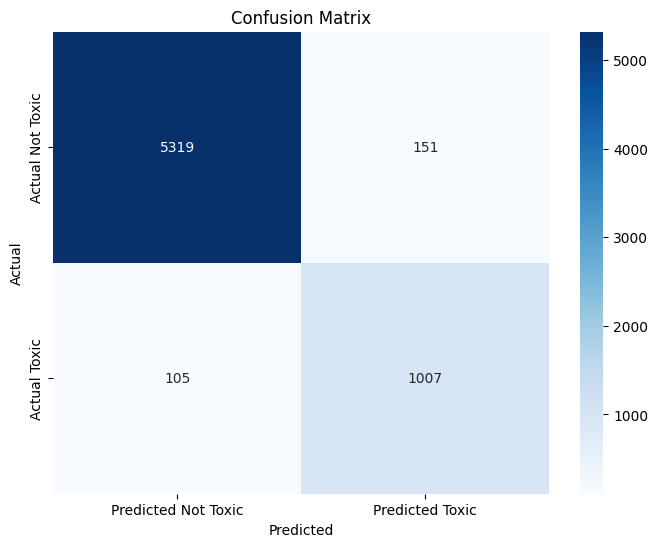

In [17]:
run_evaluation(predictor.model, val_loader_for_eval, train_cfg.DEVICE)